# Fake News Classifier - NN + BERT Embeddings
### Neural Network with Sentence Transformers (all-MiniLM-L6-v2)

**Note:** Run the NB-LB-V3 notebook first - this notebook depends on X_train, X_val, X_test, y_train, y_val, y_test

**Workflow:**
1. BERT Preprocessing
2. Calculate BERT Embeddings
3. Train Neural Network
4. Evaluation
5. Visualisation

## STEP 1 - BERT Preprocessing & Embeddings

In [9]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ================================================
# STEP 1 - BERT preprocessing (minimal!)
# No stopwords, no lemmatization!
# BERT understands context itself
# ================================================



# Load data
df = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/training_data_fixed.csv')
df.fillna('', inplace=True)

# Same split as NB-LB-V3 - same random_state!
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

def preprocess_bert(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Apply BERT preprocessing
X_train_bert = X_train.apply(preprocess_bert)
X_val_bert   = X_val.apply(preprocess_bert)
X_test_bert  = X_test.apply(preprocess_bert)

print(f'Train: {X_train_bert.shape[0]} | Val: {X_val_bert.shape[0]} | Test: {X_test_bert.shape[0]}')
print('Example:', X_train_bert.values[0])
# ================================================
# STEP 2 - Calculate BERT Embeddings
# Converts each sentence to a vector of 384 numbers
# ================================================
model_st = SentenceTransformer('all-MiniLM-L6-v2', device='mps')

print('Calculating embeddings...')
X_train_emb = model_st.encode(X_train_bert.tolist(), show_progress_bar=True)
X_val_emb   = model_st.encode(X_val_bert.tolist(),   show_progress_bar=True)
X_test_emb  = model_st.encode(X_test_bert.tolist(),  show_progress_bar=True)

print('Shape embeddings:', X_train_emb.shape)  # (21856, 384)

# ================================================
# STEP 3 - Train Neural Network on embeddings
# ================================================
model_nn_bert = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_emb.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_nn_bert.compile(
    optimizer=Adam(),  # standaard is 0.001
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn_bert.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model_nn_bert.fit(
    X_train_emb, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_emb, y_val),
    callbacks=[early_stop]
)

# ================================================
# STEP 4 - Evaluation
# ================================================
y_train_pred = (model_nn_bert.predict(X_train_emb) > 0.5).astype(int)
y_val_pred   = (model_nn_bert.predict(X_val_emb)   > 0.5).astype(int)
y_test_pred  = (model_nn_bert.predict(X_test_emb)  > 0.5).astype(int)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val,   y_val_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
train_f1  = f1_score(y_train,       y_train_pred)
val_f1    = f1_score(y_val,         y_val_pred)
test_f1   = f1_score(y_test,        y_test_pred)

print(f'\nNN + BERT Embeddings:')
print(f'Train → Acc: {train_acc:.3f} | F1: {train_f1:.3f}')
print(f'Val   → Acc: {val_acc:.3f}   | F1: {val_f1:.3f}')
print(f'Test  → Acc: {test_acc:.3f}  | F1: {test_f1:.3f}')

Train: 21856 | Val: 5465 | Test: 6831
Example: merkel admits mistakes in the 2016 christmas market attack


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5740.13it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating embeddings...


Batches: 100%|██████████| 214/214 [00:03<00:00, 66.45it/s]


Shape embeddings: (21856, 384)


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,313 (552.00 KB)

 Trainable params: 140,545 (549.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8830 - loss: 0.2750 - val_accuracy: 0.9301 - val_loss: 0.1753
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9194 - loss: 0.1981 - val_accuracy: 0.9360 - val_loss: 0.1573
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9310 - loss: 0.1729 - val_accuracy: 0.9420 - val_loss: 0.1456
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9407 - loss: 0.1508 - val_accuracy: 0.9391 - val_loss: 0.1503
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9456 - loss: 0.1358 - val_accuracy: 0.9400 - val_loss: 0.1526
683/683 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step

NN + BERT Embeddings:
Train → Acc: 0.960 | F1: 0.960
Val   → Acc: 0.942   | F1: 0.941
Test  → Acc: 0.941  | F1: 0.940


## STEP 2 - Train Neural Network

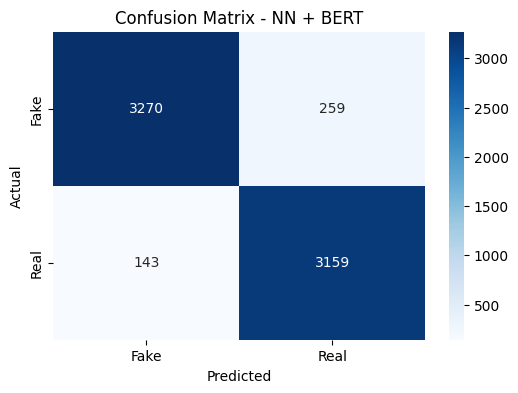

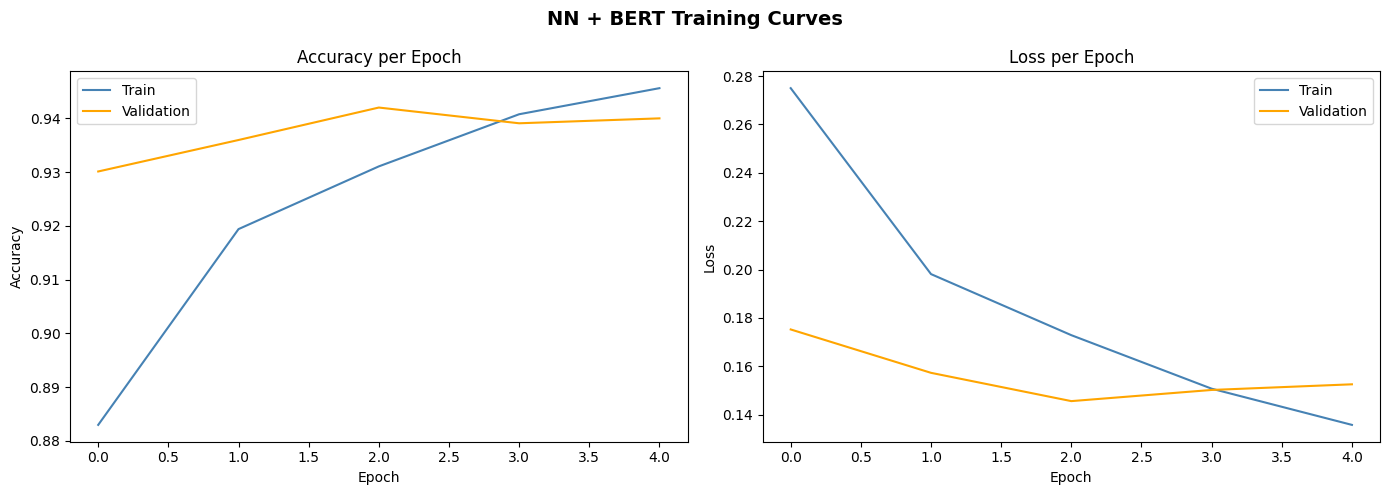

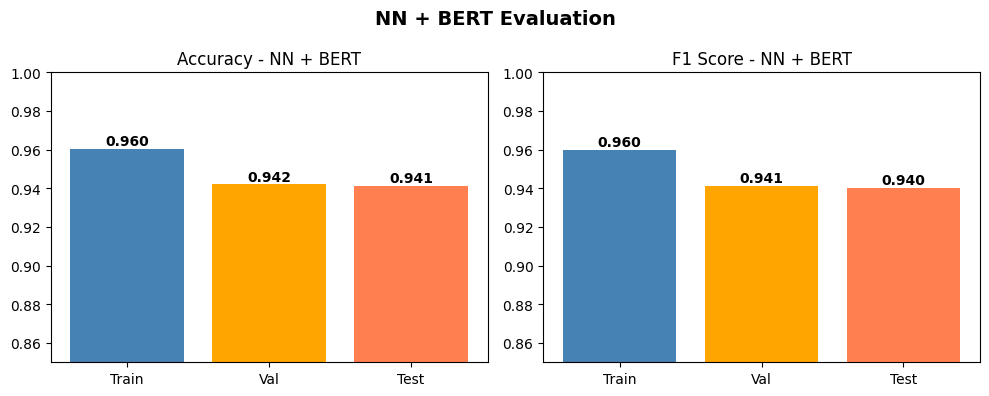

In [12]:
# Confusion Matrix NN + BERT
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - NN + BERT')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Train vs Val accuracy en loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('NN + BERT Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Train vs Test bar plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Val', 'Test'], [train_acc, val_acc, test_acc], color=['steelblue', 'orange', 'coral'])
axes[0].set_title('Accuracy - NN + BERT')
axes[0].set_ylim(0.85, 1.0)
for i, v in enumerate([train_acc, val_acc, test_acc]):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(['Train', 'Val', 'Test'], [train_f1, val_f1, test_f1], color=['steelblue', 'orange', 'coral'])
axes[1].set_title('F1 Score - NN + BERT')
axes[1].set_ylim(0.85, 1.0)
for i, v in enumerate([train_f1, val_f1, test_f1]):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('NN + BERT Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:

import gradio as gr
import random

real_pool = X_test[y_test == 1].tolist()
fake_pool = X_test[y_test == 0].tolist()

def predict(text):
    emb  = model_st.encode([preprocess_bert(text)])
    pred = model_nn_bert.predict(emb, verbose=0)[0][0]
    return f"{'🟢 REAL' if pred > 0.5 else '🔴 FAKE'} — Confidence: {max(pred, 1-pred)*100:.1f}%"

def run(headlines):
    return '\n'.join([f"{predict(h)}\n📰 {h}\n" for h in headlines])

with gr.Blocks(title='Fake News Classifier') as app:
    gr.Markdown('# 🔍 Fake News Classifier — NN + BERT')
    inp = gr.Textbox(label='Enter headline manually')
    with gr.Row():
        b1 = gr.Button('Predict',                          variant='primary')
        b2 = gr.Button('🟢 Sample REAL news scraper', variant='secondary')
        b3 = gr.Button('🔴 Sample FAKE news scraper', variant='secondary')
    out = gr.Textbox(label='Results', lines=12)
    b1.click(fn=predict,                                   inputs=inp,  outputs=out)
    b2.click(fn=lambda: run(random.sample(real_pool, 5)), inputs=None, outputs=out)
    b3.click(fn=lambda: run(random.sample(fake_pool, 5)), inputs=None, outputs=out)

app.launch(share=True)


* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://8846c3996d35d7a116.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
